## Defining Preprocessing Steps for Text Normalization

In [1]:
# The `preProcess` function demonstrates the preprocessing steps applied to create the `lemma_text` column.
# This involved a two-step approach:
# 1. Lemmatization: Standardizing words to their base dictionary forms for semantic consistency.
# 2. Stemming: Further reducing words to their root forms for feature minimization.
# Note: The preProcess function is not used in this script as the datasets are already preprocessed now, 
# it is included to show the preprocessing workflow.

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # Vectorizers for feature extraction
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, ConfusionMatrixDisplay  # Evaluation metrics
import re  # For regular expressions
from nltk.corpus import stopwords  # To remove common stopwords
from nltk.stem.porter import PorterStemmer  # For stemming
import nltk  # For NLP tasks
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing function to clean and normalize text
def preProcess(text):
    ps = PorterStemmer()  # Initialize the Porter Stemmer
    #wordnet=WordNetLemmatizer()  # Used initially for lemmatization during preprocessing to standardize words to their base forms.
    text = re.sub('https?://\S+|www\.\S+', '', text)  # Removing any URLs
    sentences = nltk.sent_tokenize(text)  # Tokenize text into sentences
    corpus = []
    for i in range(len(sentences)):
        sentence = re.sub('[^a-zA-Z]', ' ', sentences[i])  # Replace non-alphabetic characters with spaces
        sentence = sentence.lower()  # Convert to lowercase
        sentence = sentence.split()  # Split sentence into words for stemming
        sentence = [ps.stem(word) for word in sentence if not word in set(stopwords.words('english'))]  # Remove stopwords and apply stemming
        sentence = ' '.join(sentence)  # Joining words back into a sentence
        corpus.append(sentence)  # Append processed sentence to the corpus
    result = " ".join(corpus)  # Joining all sentences back into a single string
    return result

## Loading the Datasets

In [2]:
dataset = pd.read_csv('WELFAKE_70k.csv')  # Read the dataset
pd.options.mode.chained_assignment = None  # Suppress chained assignment warning
# dataset = dataset[dataset['lemma_text'].astype(str).apply(lambda x: len(x.strip()) > 0)]

dataset = dataset.dropna()  # Remove all records with NaN values
dataset.reset_index(drop=True, inplace=True)  # Reseting the indexes, since I deleted NaN values
dataset["isFake"] = dataset["label"].apply(lambda x: 0 if (x == "REAL" or x == 1) else 1)  # Add isFake column

In [3]:
dataset

,Unnamed: 0,title,text,label,isFake,lemma_text
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,0,comment expect barack obama member fyf fukyofl...
1,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,0,demonstr gather last night exercis constitut p...
2,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,1,dozen polit activ pastor came privat dinner fr...
3,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,0,rs sarmat missil dub satan replac ss fli mile ...
4,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,0,say one time someon su southern poverti law ce...
...,...,...,...,...,...,...
70784,72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0,1,washington reuter hacker believ work russian g...
70785,72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1,0,know fantasyland republican never question cit...
70786,72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0,1,migrant refus leav train refuge camp hungari t...
70787,72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0,1,mexico citi reuter donald trump comb style buf...


## Visualizing Class Distribution

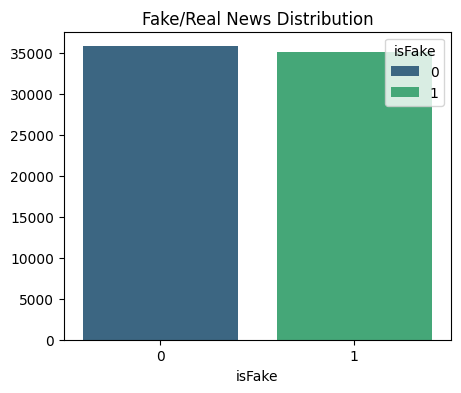

In [4]:
# Count the occurrences of each class label (Fake/Real)
class_counts = dataset['isFake'].value_counts()

# Plot class distribution
plt.figure(figsize=(5, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis', hue=class_counts.index, dodge=False)
plt.title('Fake/Real News Distribution')
plt.xlabel('isFake')
plt.show()

## Splitting data into train, validation, and test sets

In [5]:
train_set, temp_set = train_test_split(dataset, test_size=0.3, random_state=42)  # 70% train, 30% temp
valid_set, test_set = train_test_split(temp_set, test_size=0.33, random_state=42)  # 20% validation, 10% test

# Reset the indexes for validation and test sets to maintain consistency
test_set.reset_index(drop=True, inplace=True)
valid_set.reset_index(drop=True, inplace=True)

## Feature Extraction

In [6]:
vectorizer = CountVectorizer(max_features=5000, ngram_range=(1, 2))  # Here I can switch between CountVectorizer and TfidfVectorizer
X_train = vectorizer.fit_transform(train_set['lemma_text'])
X_valid = vectorizer.transform(valid_set['lemma_text'])
X_test = vectorizer.transform(test_set['lemma_text'])

# Extracting labels for train, validation, and test sets
y_train = train_set['isFake'].values
y_valid = valid_set['isFake'].values
y_test = test_set['isFake'].values

# Display the shape of the training set to confirm feature extraction
print("\nShape of the training set:")
print(X_train.shape)


Shape of the training set:
(49552, 5000)


# First Method : Support Vector Machine (SVM)


--- SVM Training Process ---


c:\Users\1msk3\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Finished SVM training.

--- Results ---
SVM Validation Accuracy: 93.58%

SVM Test Accuracy: 94.14%
SVM Precision: 94.72%
SVM Recall: 93.39%
SVM F1 Score: 94.05%


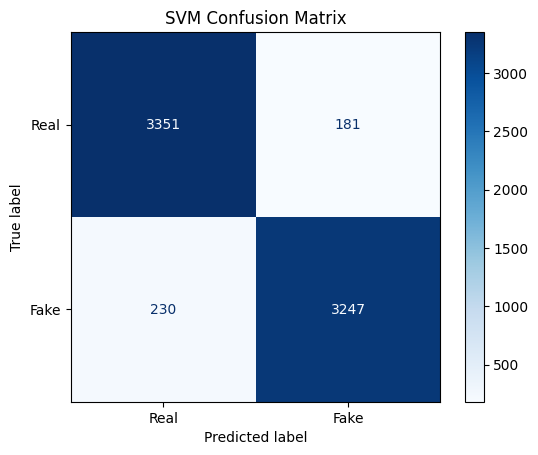

In [7]:
# Initialize and train the SVM model with increased iterations for convergence
print("\n--- SVM Training Process ---")
svm_model = LinearSVC(max_iter=8000, dual=False)
svm_model.fit(X_train, y_train)
print("Finished SVM training.")

# Validate and test the SVM model
valid_predictions = svm_model.predict(X_valid)
test_predictions = svm_model.predict(X_test)

# Calculate performance metrics for validation and test sets
val_accuracy = accuracy_score(y_valid, valid_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)
svm_precision = precision_score(y_test, test_predictions)
svm_recall = recall_score(y_test, test_predictions)
svm_f1 = f1_score(y_test, test_predictions)

# Print performance metrics for SVM
print("\n--- Results ---")
print("SVM Validation Accuracy: {:.2f}%\n".format(val_accuracy * 100))
print("SVM Test Accuracy: {:.2f}%".format(test_accuracy * 100))
print(f'SVM Precision: {svm_precision:.2%}')
print(f'SVM Recall: {svm_recall:.2%}')
print(f'SVM F1 Score: {svm_f1:.2%}')

# Display the confusion matrix for the SVM model
svm_conf_matrix_test = confusion_matrix(y_test, test_predictions)
disp = ConfusionMatrixDisplay(svm_conf_matrix_test, display_labels=['Real', 'Fake'])
disp.plot(cmap=plt.cm.Blues, values_format='.0f')
plt.title('SVM Confusion Matrix')
plt.show()

# Second Method : Random Forest Ensemble


--- Random Forest Training Process ---
Fitting classifier 0 for Training Set with bootstrap sample shape: (49552 samples (rows), 5000 features (columns))
Finished fitting classifier 0
Fitting classifier 1 for Training Set with bootstrap sample shape: (49552 samples (rows), 5000 features (columns))
Finished fitting classifier 1
Fitting classifier 2 for Training Set with bootstrap sample shape: (49552 samples (rows), 5000 features (columns))
Finished fitting classifier 2
Fitting classifier 3 for Training Set with bootstrap sample shape: (49552 samples (rows), 5000 features (columns))
Finished fitting classifier 3

--- Results ---
Random Forest Validation Accuracy: 94.26%

Random Forest Test Accuracy: 95.22%
Random Forest Precision: 96.59%
Random Forest Recall: 93.67%
Random Forest F1 Score: 95.11%


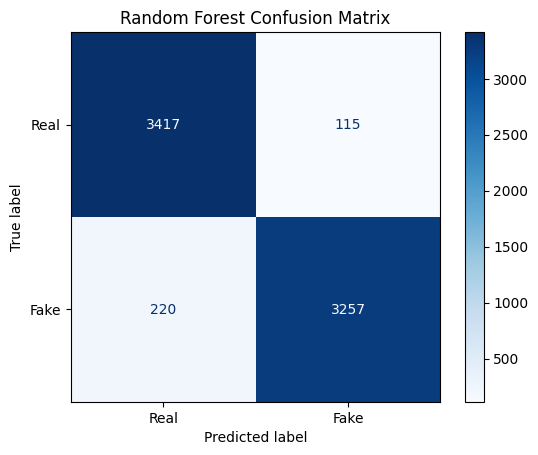

In [9]:
# Define a custom ensemble class for Random Forest with bootstrapped samples
class RandomForestEnsemble:
    def __init__(self, base_classifier, n_classifiers=4):
        self.base_classifier = base_classifier
        self.n_classifiers = n_classifiers
        self.classifiers = [base_classifier.__class__() for _ in range(n_classifiers)]

    def fit(self, X, y, dataset_name="Training Set", debug=True):
        for i, classifier in enumerate(self.classifiers):
            # Create bootstrapped samples
            indices = np.random.choice(len(X), len(X), replace=True)
            X_bootstrap, y_bootstrap = X[indices], y[indices]

            if debug:
                print(f"Fitting classifier {i} for {dataset_name} with bootstrap sample shape: ({X_bootstrap.shape[0]} samples (rows), {X_bootstrap.shape[1]} features (columns))")

            classifier.fit(X_bootstrap, y_bootstrap)

            if debug:
                print(f"Finished fitting classifier {i}")

    def predict(self, X, threshold=0.5):
        # Combine predictions from all classifiers
        predictions = np.zeros((len(self.classifiers), X.shape[0]))
        for i, classifier in enumerate(self.classifiers):
            predictions[i, :] = classifier.predict_proba(X)[:, 1]
        final_predictions = np.mean(predictions, axis=0)
        return (final_predictions > threshold).astype(int)

# Initialize the base Random Forest classifier
base_rf = RandomForestClassifier(n_estimators=40)
ensemble_rf = RandomForestEnsemble(base_rf)

# Train the Random Forest ensemble
print("\n--- Random Forest Training Process ---")
ensemble_rf.fit(X_train.toarray(), y_train, dataset_name="Training Set", debug=True)

# Validate and test the Random Forest Ensemble model
valid_predictions_rf = ensemble_rf.predict(X_valid.toarray())
test_predictions_rf = ensemble_rf.predict(X_test.toarray())

# Calculate performance metrics for validation and test sets
val_accuracy_rf = accuracy_score(y_valid, valid_predictions_rf)
test_accuracy_rf = accuracy_score(y_test, test_predictions_rf)
rf_precision = precision_score(y_test, test_predictions_rf)
rf_recall = recall_score(y_test, test_predictions_rf)
rf_f1 = f1_score(y_test, test_predictions_rf)

# Print performance metrics
print("\n--- Results ---")
print("Random Forest Validation Accuracy: {:.2f}%\n".format(val_accuracy_rf * 100))
print("Random Forest Test Accuracy: {:.2f}%".format(test_accuracy_rf * 100))
print(f'Random Forest Precision: {rf_precision:.2%}')
print(f'Random Forest Recall: {rf_recall:.2%}')
print(f'Random Forest F1 Score: {rf_f1:.2%}')

# Display the confusion matrix for the Random Forest model
rf_conf_matrix_test = confusion_matrix(y_test, test_predictions_rf)
disp = ConfusionMatrixDisplay(rf_conf_matrix_test, display_labels=['Real', 'Fake'])
disp.plot(cmap=plt.cm.Blues, values_format='.0f')
plt.title('Random Forest Confusion Matrix')
plt.show()